In [50]:
import torch 
import torchvision
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import os
import zipfile
import requests
import pandas as pd
from PIL import Image
from torchinfo import summary
from torchvision import datasets, models, transforms
from torchinfo import summary
from torch.utils.data import DataLoader

plt.style.use('ggplot')


In [51]:
def download_file(url, save_name):
    url = url
    if not os.path.exists(save_name):
        file = requests.get(url)
        open(save_name, 'wb').write(file.content)
        
download_file(
    'https://www.dropbox.com/s/0ltu2bsja3sb2j4/caltech256_subset.zip?dl=1',
    'caltech256_subset.zip'
)

In [52]:
file = 'caltech256_subset.zip'
with zipfile.ZipFile(file) as z:
    print('extraction...')
    z.extractall()
    print('Done!')


extraction...
Done!


In [53]:
image_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.48, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

In [54]:
dataset = 'caltech256_subset'

train_directory = os.path.join(dataset, 'train')
valid_directory = os.path.join(dataset, 'valid')
test_directory = os.path.join(dataset, 'test')

batch_size = 32

num_classes = len(os.listdir(valid_directory))
print(num_classes)

data = {
    'train': datasets.ImageFolder(root=train_directory, transform=image_transforms['train']),
    'valid': datasets.ImageFolder(root=valid_directory, transform=image_transforms['valid']),
    'test': datasets.ImageFolder(root=test_directory, transform=image_transforms['test'])
}

idx_to_class = {v: k for k, v in data['train'].class_to_idx.items()}
print('class to idx : {}'.format(data['train'].class_to_idx))
print(idx_to_class)

train_data_size = len(data['train'])
valid_data_size = len(data['valid'])
test_data_size = len(data['test'])

train_data_loader = DataLoader(data['train'], batch_size=batch_size, shuffle=True)
valid_data_loader = DataLoader(data['valid'], batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(data['test'], batch_size=batch_size, shuffle=True)

10
class to idx : {'bear': 0, 'chimp': 1, 'giraffe': 2, 'gorilla': 3, 'llama': 4, 'ostrich': 5, 'porcupine': 6, 'skunk': 7, 'triceratops': 8, 'zebra': 9}
{0: 'bear', 1: 'chimp', 2: 'giraffe', 3: 'gorilla', 4: 'llama', 5: 'ostrich', 6: 'porcupine', 7: 'skunk', 8: 'triceratops', 9: 'zebra'}


In [55]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Number of training samples: {train_data_size}')
print(f'Number of validation samples: {valid_data_size}')
print(f'Number of test samples: {test_data_size}')

print('device : {}'.format(device))

Number of training samples: 600
Number of validation samples: 100
Number of test samples: 100
device : cpu


In [56]:
resnet50 = models.resnet50(weights='DEFAULT')
resnet50 = resnet50.to(device)

In [57]:
for param in resnet50.parameters():
    param.requires_grad = False

In [58]:
fc_inputs = resnet50.fc.in_features
print('fc_inputs : {}'.format(fc_inputs))

resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes),
    nn.LogSoftmax(dim=1)
)

resnet50 = resnet50.to(device)
loss_func = nn.NLLLoss()

learning_rate = 0.01

optimizer = optim.SGD(
    params=resnet50.parameters(),
    lr=learning_rate,
    momentum=0.9
)

fc_inputs : 2048


In [59]:
def train_and_validate(model, loss_criterion, optimizer, epochs=25):
    start = time.time()
    history = []
    best_loss = 100000.0
    best_epoch = None
    
    for epoch in range(epochs):
        epoch_start = time.time()
        print('Epoch: {}/{}'.format(epoch+1, epochs))
        
        model.train()
        
        train_loss = 0.0
        train_acc = 0.0
        
        valid_loss = 0.0
        valid_acc = 0.0
        
        # train
        for i, (inputs, labels) in enumerate(train_data_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))
            
            acc = torch.mean(correct_counts.type(torch.FloatTensor))
            
            train_acc += acc.item() * inputs.size(0)
        
        # validation
        with torch.no_grad():
            model.eval()
        
            for j, (inputs, labels) in enumerate(valid_data_loader):
                inputs = inputs.to(device)
                lables = labels.to(device)
                
                outputs = model(inputs)
                
                loss = loss_criterion(outputs, labels)
                
                valid_loss += loss.item() * inputs.size(0)
                
                ret, predictions = torch.max(outputs.data, 1)
                correct_counts = predictions.eq(labels.data.view_as(predictions))
                
                acc = torch.mean(correct_counts.type(torch.FloatTensor))
                valid_acc += acc.item() * inputs.size(0)
                
        
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_epoch = epoch
            torch.save(model, 'best_model.pt')
        
        
        avg_train_loss = train_loss / train_data_size
        avg_train_acc = train_acc / train_data_size
        
        avg_valid_loss = valid_loss / valid_data_size
        avg_valid_acc = valid_acc / valid_data_size
        
        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])
        
        epoch_end = time.time()
        
        print("Epoch : {:03d}, Training: Loss - {:.4f}, Accuracy - {:.4f}%, \n\t\tValidation : Loss - {:.4f}, Accuracy - {:.4f}%, Time: {:.4f}s".format(epoch, avg_train_loss, avg_train_acc*100, avg_valid_loss, avg_valid_acc*100, epoch_end-epoch_start))

    return model, history, best_epoch

In [60]:
print(summary(resnet50, input_size=(batch_size, 3, 224, 224)))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 10]                  --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]   

In [61]:
num_epochs = 25
trained_model, history, best_epoch = train_and_validate(resnet50, loss_func, optimizer, num_epochs)

torch.save(history, dataset+'_history.pt')

Epoch: 1/25
Epoch : 000, Training: Loss - 2.2171, Accuracy - 40.0000%, 
		Validation : Loss - 2.0326, Accuracy - 89.0000%, Time: 45.1753s
Epoch: 2/25
Epoch : 001, Training: Loss - 1.7334, Accuracy - 86.0000%, 
		Validation : Loss - 1.3031, Accuracy - 94.0000%, Time: 39.7038s
Epoch: 3/25
Epoch : 002, Training: Loss - 0.9158, Accuracy - 91.6667%, 
		Validation : Loss - 0.5897, Accuracy - 94.0000%, Time: 39.6954s
Epoch: 4/25
Epoch : 003, Training: Loss - 0.4279, Accuracy - 94.3333%, 
		Validation : Loss - 0.3352, Accuracy - 95.0000%, Time: 39.6657s
Epoch: 5/25
Epoch : 004, Training: Loss - 0.2618, Accuracy - 95.0000%, 
		Validation : Loss - 0.2419, Accuracy - 96.0000%, Time: 39.7579s
Epoch: 6/25
Epoch : 005, Training: Loss - 0.2146, Accuracy - 96.3333%, 
		Validation : Loss - 0.2228, Accuracy - 95.0000%, Time: 39.8778s
Epoch: 7/25
Epoch : 006, Training: Loss - 0.1807, Accuracy - 95.8333%, 
		Validation : Loss - 0.1993, Accuracy - 96.0000%, Time: 40.2182s
Epoch: 8/25
Epoch : 007, Training:

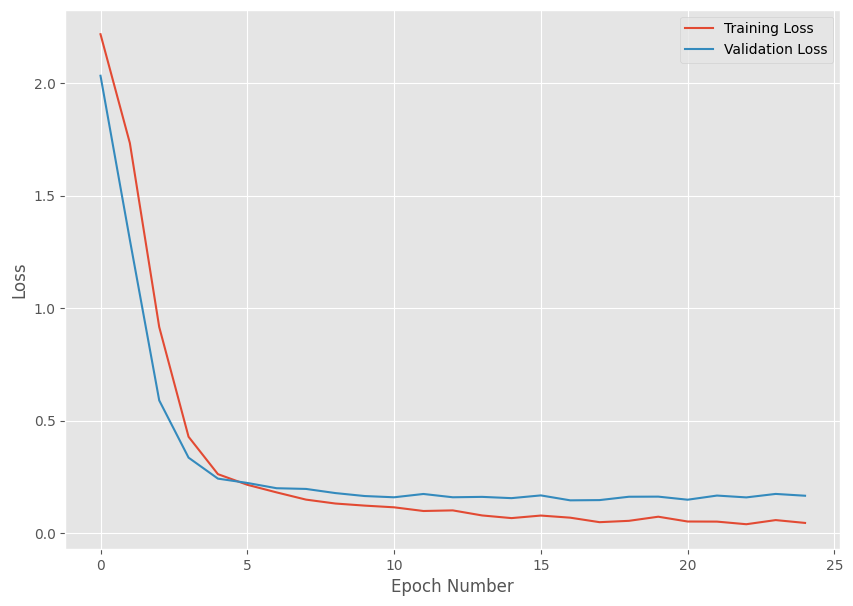

In [62]:
import numpy as np
plt.figure(figsize=(10, 7))
history = np.array(history)
plt.plot(history[:, 0:2])
plt.legend(['Training Loss', 'Validation Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.savefig('loss_curve.png')
plt.show()

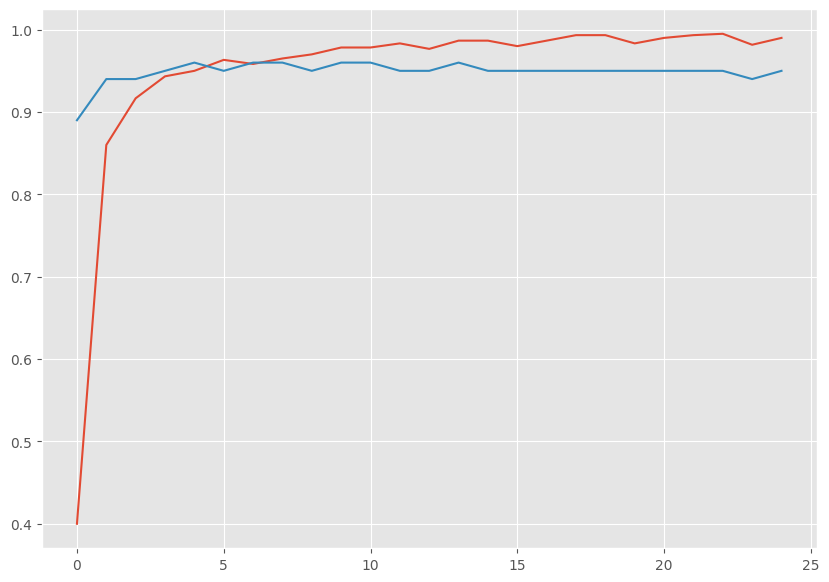

In [64]:
plt.figure(figsize=(10,7))
plt.plot(history[:, 2:4])
plt.show()

In [90]:
def computeTestSetAcccuracy(model, loss_criterion):
    test_loss = 0.0
    test_acc = 0.0
    
    with torch.no_grad():
        model.eval()
        for j, (inputs, labels) in enumerate(test_data_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = loss_criterion(outputs, labels)
            
            test_loss = loss.item() * inputs.size(0)
            
            _, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))
            
            acc = torch.mean(correct_counts.type(torch.FloatTensor))
            
            test_acc += acc.item() * inputs.size(0)
            
            print(f"Test Batch number: {j:03d}, Test: Loss: {loss.item():.4f}, Accuracy: {acc.item():.4f}")

    avg_test_loss = test_loss / test_data_size
    avg_test_acc = test_acc / test_data_size
    print("Test loss: {:.4f}".format(avg_test_loss))
    print("Test accuracy: {:.4f}".format(avg_test_acc))

In [91]:
computeTestSetAcccuracy(trained_model, loss_func)

Test Batch number: 000, Test: Loss: 0.1704, Accuracy: 0.9375
Test Batch number: 001, Test: Loss: 0.1074, Accuracy: 0.9688
Test Batch number: 002, Test: Loss: 0.0728, Accuracy: 1.0000
Test Batch number: 003, Test: Loss: 0.0369, Accuracy: 1.0000
Test loss: 0.0015
Test accuracy: 0.9700


In [92]:
def predict(model, test_image_name):
    transform = image_transforms['test']
    test_image = Image.open(test_image_name)
    
    plt.figure(figsize=(10,7))
    plt.imshow(test_image)
    plt.axis('off')
    
    test_image_tensor = transform(test_image)
    print('test image tensor shape : ', test_image_tensor.shape)
    
    test_image_tensor = test_image_tensor.view(1,3,224,224)
    
    if torch.cuda.is_available():
        test_image_tensor = test_image_tensor.cuda()
        
    with torch.no_grad():
        model.eval()
        out = trained_model(test_image_tensor)
        ps = torch.exp(out)
        
        topk, topclass = ps.topk(3, dim=1)
        cls = idx_to_class[topclass.cpu().numpy()[0][0]]
        score = topk.cpu().numpy()[0][0]
        
        for i in range(3):
            print(f"Prediction {i+1}: {idx_to_class[topclass.cpu().numpy()[0][i]]}",
                  f"Score: {topk.cpu().numpy()[0][i]*100:.3f}%")

test image tensor shape :  torch.Size([3, 224, 224])
Prediction 1: skunk Score: 99.899%
Prediction 2: porcupine Score: 0.073%
Prediction 3: zebra Score: 0.007%


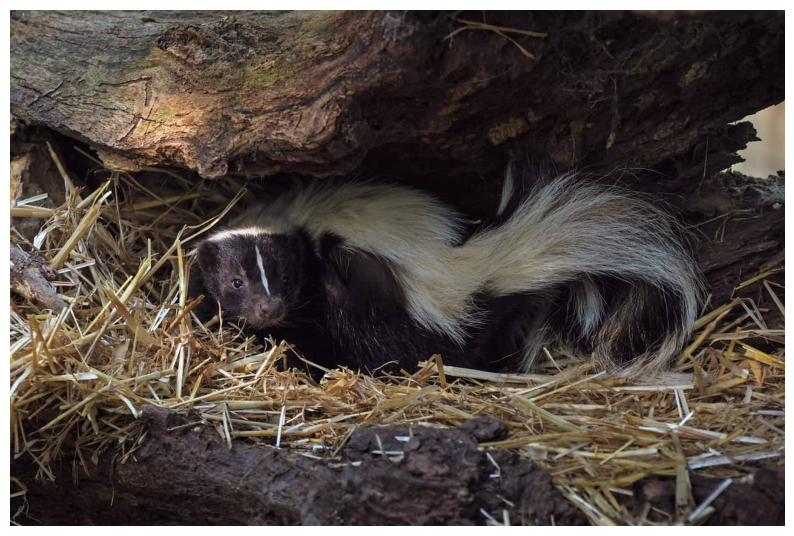

In [102]:
predict(trained_model, './images/skunk.jpg')

test image tensor shape :  torch.Size([3, 224, 224])
Prediction 1: zebra Score: 99.984%
Prediction 2: giraffe Score: 0.008%
Prediction 3: ostrich Score: 0.002%


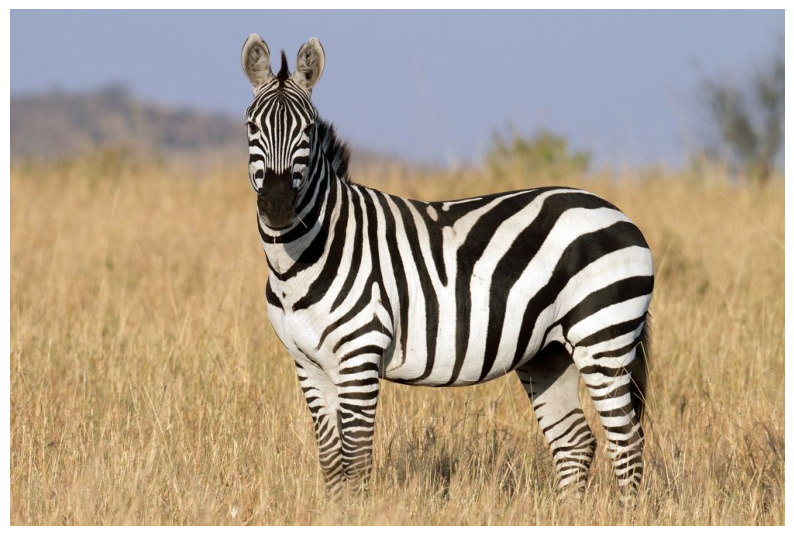

In [103]:
predict(trained_model, './images/Zebra.jpg')

test image tensor shape :  torch.Size([3, 224, 224])
Prediction 1: llama Score: 55.586%
Prediction 2: chimp Score: 15.001%
Prediction 3: bear Score: 13.020%


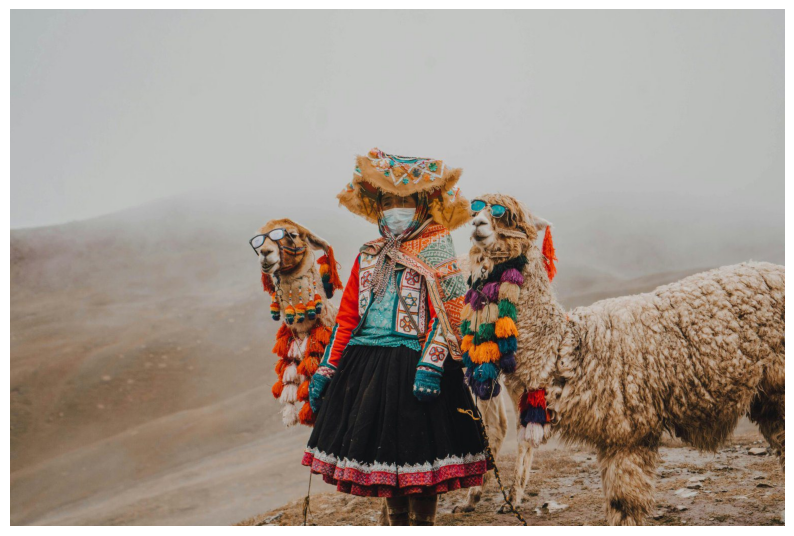

In [104]:
predict(trained_model, './images/llama-scaled.jpg')

test image tensor shape :  torch.Size([3, 224, 224])
Prediction 1: llama Score: 99.933%
Prediction 2: giraffe Score: 0.037%
Prediction 3: ostrich Score: 0.012%


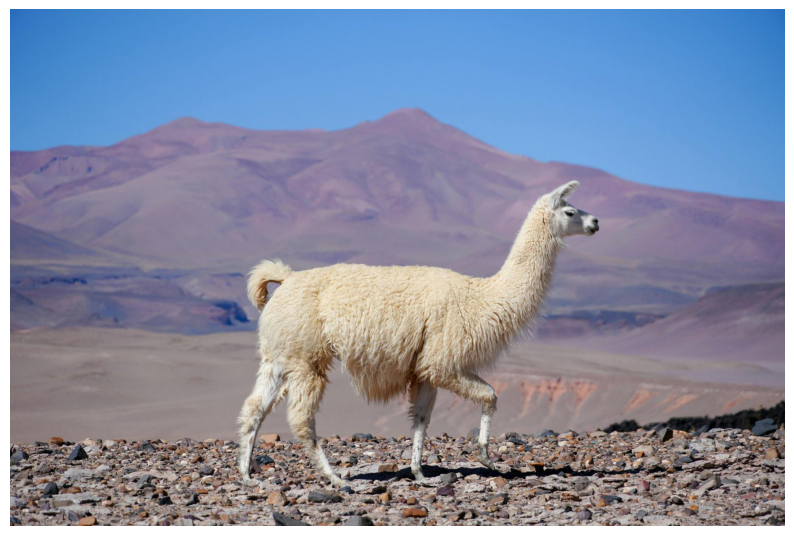

In [106]:
predict(trained_model, './images/llama_-scaled.jpg')